In [6]:
# Imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from pprint import pprint
%matplotlib inline

In [33]:
# Load the iris dataset
iris = load_iris()

# Explore the dataset using .keys()
print("Dataset keys:", iris.keys())

Dataset keys: dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [34]:
# Print the shape and type of 'data'
print("Type of 'data':", type(iris['data']))
print("Shape of 'data':", iris['data'].shape)

Type of 'data': <class 'numpy.ndarray'>
Shape of 'data': (150, 4)


In [2]:
# Store 'data' and 'feature_names' in distinct variables
data = iris['data']
feature_names = iris['feature_names']


Type of 'data': <class 'numpy.ndarray'>
Shape of 'data': (150, 4)

Summary Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  


In [16]:
# Create a pandas dataframe with 'data' and use 'feature_names' for column names
df_iris = pd.DataFrame(data, columns=feature_names)
pprint(df_iris)
print(df.shape)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]
(150, 4)


In [17]:
# Get the summary statistics for this dataframe using .describe()
print("\nSummary Statistics:")
print(df_iris.describe())


Summary Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  


In [24]:
# Subset the dataframe to keep only the first 50 rows
df_iris_subset = df_iris.head(50)
pprint(df_iris_subset)

    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                 5.1               3.5                1.4               0.2
1                 4.9               3.0                1.4               0.2
2                 4.7               3.2                1.3               0.2
3                 4.6               3.1                1.5               0.2
4                 5.0               3.6                1.4               0.2
5                 5.4               3.9                1.7               0.4
6                 4.6               3.4                1.4               0.3
7                 5.0               3.4                1.5               0.2
8                 4.4               2.9                1.4               0.2
9                 4.9               3.1                1.5               0.1
10                5.4               3.7                1.5               0.2
11                4.8               3.4                1.6               0.2

In [30]:
# Are there any extreme sepal length values? 
sepal_length = df_iris_subset['sepal length (cm)']
mean_sl = sepal_length.mean()
std_sl = sepal_length.std()

extreme_sepal_lengths = []
for val in sepal_length:
    # Calculate the z-score: (value - mean) / std
    z_score = abs(val - mean_sl) / std_sl
    if z_score > 3.9:
        extreme_sepal_lengths.append(val)

print("Extreme sepal length values:", extreme_sepal_lengths)

Extreme sepal length values: []


In [31]:
# Automating the operation by writing a function
def find_extreme_values(column_data):
    mean_val = column_data.mean()
    std_val = column_data.std()
    extremes = []
    
    for val in column_data:
        z_score = abs(val - mean_val) / std_val
        if z_score > 3.9:
            extremes.append(val)
            
    return extremes

In [32]:
# Test the function on all features in the dataframe
print("\nExtreme values across all features:")
for col in df.columns:
    extremes = find_extreme_values(df_iris_subset[col])
    print(f"{col}: {extremes}")


Extreme values across all features:
sepal length (cm): []
sepal width (cm): []
petal length (cm): []
petal width (cm): []


## What does the boxplot function tell us?

Ans: To display the distribution of a dataset, which shows the median, the 25th and 75th percentiles, and the min and max of the range of the data. It is also visually prompt for outliers identification.

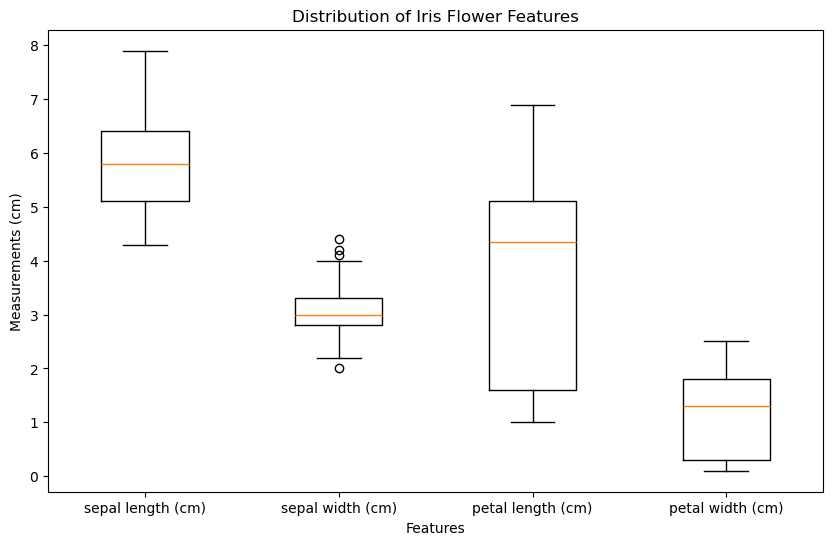

Done


In [27]:
# Use this function to plot the boxplot distribution for features. 
# Try adding a title and name for axis.
plt.figure(figsize=(10, 6))

# pass the columns of the dataframe as a list of arrays to the boxplot function
plt.boxplot([df[col] for col in df.columns], labels=df.columns)

# Set the title & lables of the plot
plt.title('Distribution of Iris Flower Features')
plt.xlabel('Features')
plt.ylabel('Measurements (cm)')

# Save the plot as a png BEFORE calling plt.show()
plt.savefig('iris_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

# Save dataframe in csv format
df.to_csv('iris_dataset.csv', index=False)
print("Done")